In [31]:
from langgraph.graph import StateGraph , START , END
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
load_dotenv()
from typing import TypedDict

In [32]:
model = ChatGoogleGenerativeAI(
    model="gemini-flash-lite-latest",
    temperature=0.7
)

In [33]:
class BlogPost(TypedDict):
    title: str
    outline: str
    content: str
    rating: int

In [34]:
def create_outline(state: BlogPost) -> BlogPost:
    title = state['title']
    outline_prompt = f"Create a detailed outline for a blog post titled '{title}'."
    outline = model.invoke(outline_prompt)
    state['outline'] = outline
    return state

In [35]:
def create_blog(state: BlogPost) -> BlogPost:
    outline = state['outline']
    content_prompt = f"Write a blog post based on the following outline:\n{outline}"
    content = model.invoke(content_prompt)
    state['content'] = content
    return state

In [36]:
def rate_myblog(state: BlogPost) -> BlogPost:
    import re

    content = state['content']
    rating_prompt = f"Rate the following blog post on a scale of 1 to 10. Return only the number:\n{content}"
    response = model.invoke(rating_prompt)
    response_content = response.content

    if isinstance(response_content, list):
        response_text = " ".join(
            item.get("text", "") if isinstance(item, dict) else str(item)
            for item in response_content
        )
    else:
        response_text = str(response_content)

    rating_match = re.search(r"\b(10|[1-9])\b", response_text)
    if rating_match is None:
        raise ValueError(f"Model did not return a rating from 1 to 10: {response_text!r}")

    state['rating'] = int(rating_match.group(1))
    return state

In [37]:
graph = StateGraph(BlogPost)
graph.add_node("create_outline", create_outline)
graph.add_node("create_blog", create_blog)
graph.add_node("rate_myblog", rate_myblog)
graph.add_edge(START, "create_outline")
graph.add_edge("create_outline", "create_blog")
graph.add_edge("create_blog", "rate_myblog")
graph.add_edge("rate_myblog", END)
workflow = graph.compile()

In [38]:
initial_state = {"title": "The Future of AI in Healthcare"}
final_state = workflow.invoke(initial_state)
print(final_state["outline"])


content=[{'type': 'text', 'text': 'Here is a detailed, SEO-friendly outline for a blog post titled **"The Future of AI in Healthcare"**. \n\n---\n\n# Blog Post Outline: The Future of AI in Healthcare\n\n## **Working Title Options**\n* The Future of AI in Healthcare: Trends, Innovations, and Ethical Challenges\n* Beyond the Hype: How Artificial Intelligence is Reshaping Patient Care\n* The AI Revolution in Medicine: What the Next Decade Holds\n\n---\n\n## **I. Introduction**\n* **The Hook:** Start with a relatable scenario—imagine walking into a doctor\'s office where an algorithm has already analyzed your genome, predicted your risk of chronic illness, and tailored a precise treatment plan before you even sit down.\n* **The Context:** AI is no longer science fiction in medicine; it is rapidly transitioning from an experimental tool to a foundational pillar of modern healthcare.\n* **The Thesis Statement:** While AI promises unprecedented advancements in diagnostics, personalized medici

In [39]:
print(final_state["content"])


content=[{'type': 'text', 'text': '# The Future of AI in Healthcare: Trends, Innovations, and Ethical Challenges\n\nImagine walking into a doctor\'s office where an algorithm has already analyzed your genome, predicted your risk of chronic illness, and tailored a precise treatment plan before you even sit down. \n\nFor decades, this scenario belonged strictly to the realm of science fiction. Today, however, **artificial intelligence in medicine** is rapidly transitioning from an experimental tool to a foundational pillar of modern healthcare. \n\nWhile AI promises unprecedented advancements in diagnostics, personalized medicine, and operational efficiency, realizing its full potential will require navigating critical ethical, regulatory, and human challenges. Let’s dive into how the **future of healthcare technology** is unfolding.\n\n---\n\n## Current State vs. Future Vision: Where Are We Now?\n\nRight now, the use of **AI in healthcare** is largely foundational. Hospitals and clinics

In [40]:
print(final_state["rating"])

9


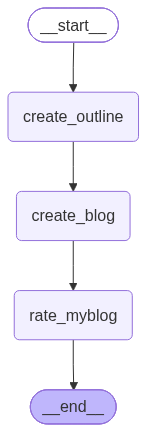

In [41]:
from IPython.core.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [42]:

response = model.invoke(prompt)

print(type(response.content))
print(response.content)

NameError: name 'prompt' is not defined